# 模型管理
- Experiment tracking涵盖创建模型的试验。在我们选定一个候选方案后，会将该方案的模型及其演化路径一并保存。
- 同时，我们也会保留参数和评估指标，以便他人能够进行评估和部署。

## 1.From experiments to a model  从实验到模型
- 机器学习的生命周期从调优tuning阶段,进入decision决策阶段，即确定哪个模型已准备好进一步使用。
- 此时，我们需要了解生成该模型的数据和代码，以及相关的参数、评估结果和文件。
- 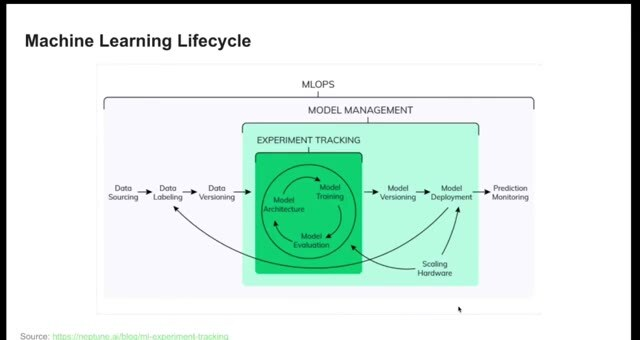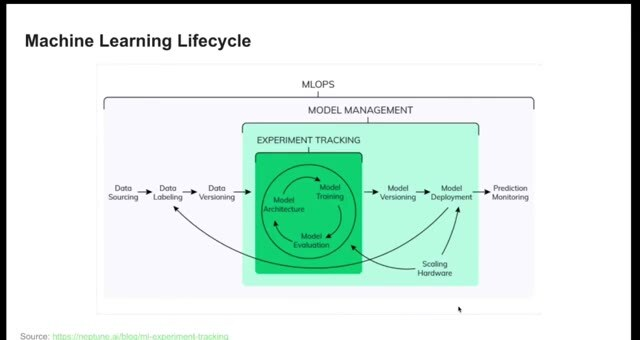

### MLflow 可以记录参数、指标、构建物和模型。其自动日志功能集成了支持的库的常见信息，从而减少了训练脚本中手动日志记录的工作量。
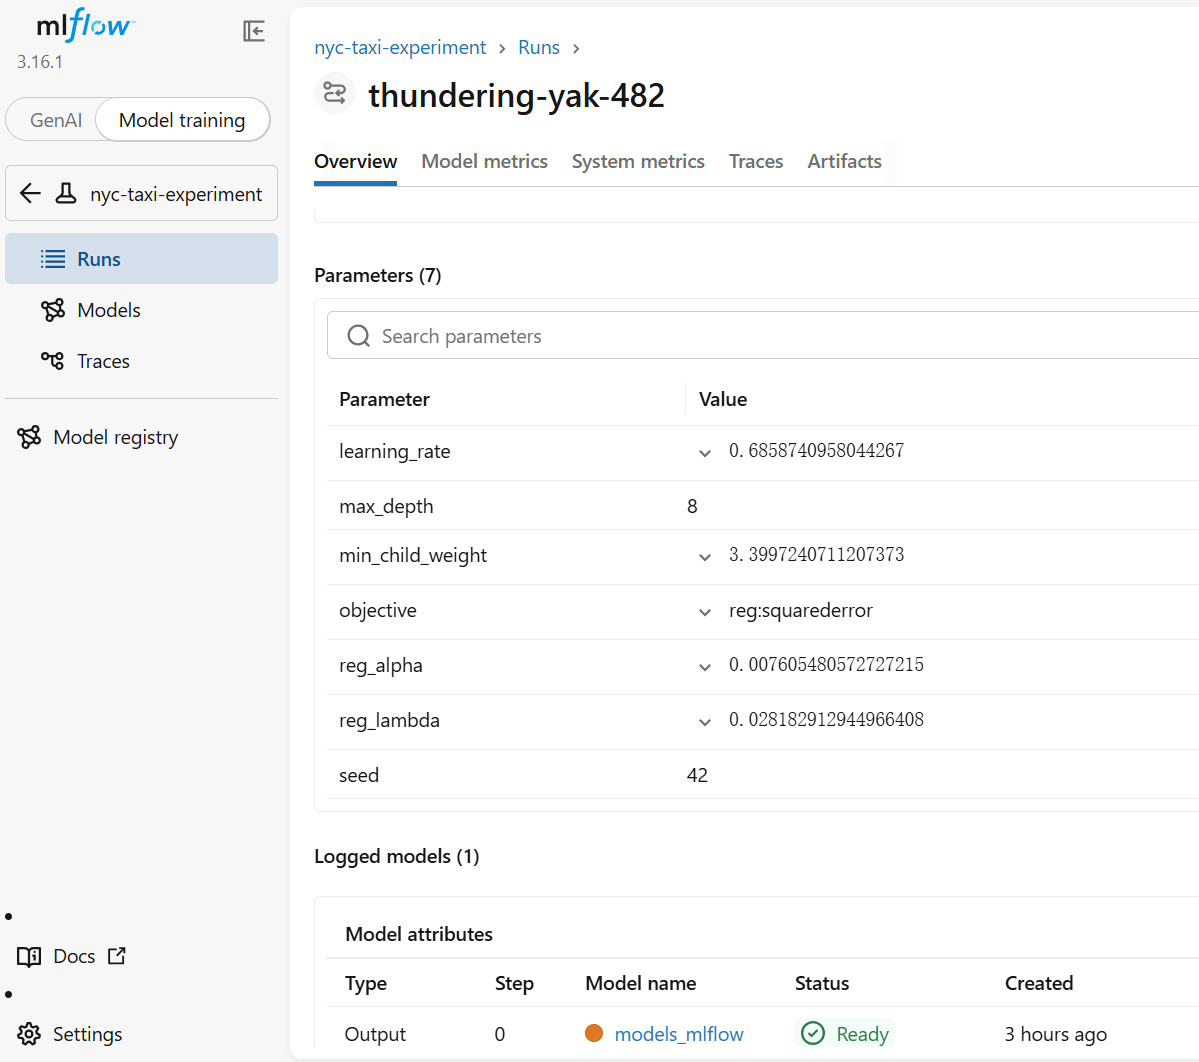

## 2.保留数据血缘 Preserve lineage 
- 运行（run）应该指向后续实际使用的那个模型产物（artifact）。
- 把训练和验证数据的引用存在同一个 run 里，同时把模型参数、评估指标和模型文件也放在那里。
- 这样，部署环节就能获得足够的信息，知道自己到底在服务什么。

# Model Registry
- Model Registry为建模和部署团队提供一个共享的模型版本列表。
- 它并不直接部署模型，而是记录哪些版本是候选版本、每个版本由哪个run产生，以及团队在流程的某个阶段选择了哪个版本。

## 1. Register a model version   注册模型版本

- 比较完运行结果后，将选定的模型注册到 MLflow。
- 为已注册的模型赋予一个有意义的名称，并附上创建该模型的运行记录。
- Model Registry会保留版本号，并将其链接回原始运行。
- 部署工程师可以在发布版本前查看参数、性能、模型大小和环境信息。
- 将这些信息保存在Model Registry中，有助于训练模型人员与实际运行该模型的人员之间更好地沟通。

In [ ]:
# 下面这种方式，不建议采纳，不需要再训练阶段，将构建物直接进行 模型注册，应该再后期，根据训练情况，进行模型注册
#  通过这种方式，可以给模型增加版本信息，registered_model_name="nyc-taxi-xgboost" 这个很关键
 mlflow.xgboost.log_model(booster, artifact_path="models_mlflow",registered_model_name="nyc-taxi-xgboost") 
#  如果模型 nyc-taxi-xgboost 不存在 → 创建模型，版本 = Version 1，
#  如果已存在 → 新增一个版本，版本 = Version 2
#  再跑一次 → Version 3

## 2.管理版本和回滚
- 用描述和标签记录版本的用途。
- 版本可以通过预备和制作等标签移动，旧版本可以保留用于回滚。
- Model Registry提供元数据和标签。
- CI/CD 或其他部署过程执行实际部署。

## 3.使用MlflowClient 来管理模型

###  MlflowClient 是 MLflow 的编程接口，用来：
- 管理实验（list_experiments、create_experiment）
- 搜索 Run（search_runs）
- 管理模型注册表（注册版本、切换阶段、加描述）
- 它相当于用代码代替 UI 操作。

In [2]:
from mlflow.tracking import MlflowClient

MLFLOW_TRACKING_URI = "sqlite:///mlflow.db"
client = MlflowClient(tracking_uri=MLFLOW_TRACKING_URI)

In [7]:
# 列出所有实验
client.search_experiments()

[<Experiment: artifact_location='/mnt/d/develop/mlops/mlops/mlruns/1', creation_time=1790558381180, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1790558381180, lifecycle_stage='active', name='nyc-taxi-experiment', tags={}, trace_location=None, workspace='default'>,
 <Experiment: artifact_location='mlflow-artifacts:/0', creation_time=1790558152066, effective_trace_archival_retention=None, experiment_id='0', last_update_time=1790558152066, lifecycle_stage='active', name='Default', tags={}, trace_location=None, workspace='default'>]

In [8]:
# 创建一个新实验
client.create_experiment(name="my-cool-experiment")

'2'

In [9]:
# 搜索 Run ，用代码筛选最佳 Run
from mlflow.entities import ViewType

runs = client.search_runs(
    experiment_ids='1',
    filter_string="metrics.rmse < 8",
    run_view_type=ViewType.ACTIVE_ONLY,  # 只看活跃的，排除已删除的
    max_results=5,                       # 最多返回 5 条
    order_by=["metrics.rmse ASC"]        # 按 rmse 升序
)

In [10]:
for run in runs:
    print(f"run id: {run.info.run_id}, rmse: {run.data.metrics['rmse']:.4f}")

run id: 9f0bc7f7b69c486ca6f0ead47acac039, rmse: 4.2384
run id: 631976ba3a654ab6b0eee9f819cb3a99, rmse: 4.2398
run id: 4eb63881bc1f4014bf7655c2f65824b0, rmse: 4.2398
run id: eb1393d9dfe74f478fdeac50ed0520fc, rmse: 4.2581
run id: 7550cc7ccddb41ac925098bfc2b906e6, rmse: 4.2712


## 4.与模型注册表交互（将构建物，进行模型注册）

In [12]:
import mlflow

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)

In [13]:
# 以下这种模型注册方法，如果在训练的时候没有做类似这样的配置： 
# mlflow.xgboost.log_model(booster, artifact_path="models_mlflow",registered_model_name="nyc-taxi-xgboost") 
# 只保留了artifact_path="models_mlflow" 这样的配置，如果对  artifact 满意，则需要将对应的 artifact 注册为模型
# 下例，就是将mlflow.xgboost.log_model(booster, artifact_path="models_mlflow")  这样配置的训练，将其 artifact 注册为模型的方式

In [15]:
run_id = "4eb63881bc1f4014bf7655c2f65824b0"
model_uri = f"runs:/{run_id}/models_mlflow"
mlflow.register_model(model_uri=model_uri, name="nyc-taxi-regressor")

Registered model 'nyc-taxi-regressor' already exists. Creating a new version of this model...
2026/09/29 10:51:43 WARNING mlflow.tracking._model_registry.fluent: Run with id 4eb63881bc1f4014bf7655c2f65824b0 has no artifacts at artifact path 'models_mlflow', registering model based on models:/m-71873092eb6e4b3c9033d472ae7cf58b instead
Created version '1' of model 'nyc-taxi-regressor'.


<ModelVersion: aliases=[], creation_timestamp=1790650304015, current_stage='None', deployment_job_state=None, description=None, last_updated_timestamp=1790650304015, metrics=None, model_id=None, name='nyc-taxi-regressor', params=None, run_id='4eb63881bc1f4014bf7655c2f65824b0', run_link=None, source='models:/m-71873092eb6e4b3c9033d472ae7cf58b', status='READY', status_message=None, tags={}, user_id=None, version=1, workspace='default'>

In [16]:
# 继续执行同样的代码，版本号会变化  version=2
run_id = "4eb63881bc1f4014bf7655c2f65824b0"
model_uri = f"runs:/{run_id}/models_mlflow"
mlflow.register_model(model_uri=model_uri, name="nyc-taxi-regressor")

Registered model 'nyc-taxi-regressor' already exists. Creating a new version of this model...
2026/09/29 10:54:10 WARNING mlflow.tracking._model_registry.fluent: Run with id 4eb63881bc1f4014bf7655c2f65824b0 has no artifacts at artifact path 'models_mlflow', registering model based on models:/m-71873092eb6e4b3c9033d472ae7cf58b instead
Created version '2' of model 'nyc-taxi-regressor'.


<ModelVersion: aliases=[], creation_timestamp=1790650450695, current_stage='None', deployment_job_state=None, description=None, last_updated_timestamp=1790650450695, metrics=None, model_id=None, name='nyc-taxi-regressor', params=None, run_id='4eb63881bc1f4014bf7655c2f65824b0', run_link=None, source='models:/m-71873092eb6e4b3c9033d472ae7cf58b', status='READY', status_message=None, tags={}, user_id=None, version=2, workspace='default'>

## 5、 查看版本和阶段

In [19]:
from mlflow.tracking import MlflowClient

client = MlflowClient(tracking_uri="sqlite:///mlflow.db")

# 列出 nyc-taxi-regressor 的所有版本
for mv in client.search_model_versions("name='nyc-taxi-regressor'"):
    print(f"version: {mv.version}, stage: {mv.current_stage}, status: {mv.status}")

version: 2, stage: None, status: READY
version: 1, stage: None, status: READY


### Stage（阶段） 是模型的生命周期状态，常见有：

- Stage	  |         含义
- ——————————————————————————
- None	   |   刚注册，未分配
- Staging	|    测试/预发布
- Production  |  	生产环境
- Archived   |  	归档

## 6、 切换模型阶段

In [39]:
# 把版本2，切换到 Production 阶段
client.transition_model_version_stage(
    name='nyc-taxi-regressor',
    version=2,
    stage="Production",
    archive_existing_versions=False
)

/tmp/ipykernel_11281/909207363.py:2: FutureWarning: ``mlflow.tracking.client.MlflowClient.transition_model_version_stage`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  client.transition_model_version_stage(


<ModelVersion: aliases=[], creation_timestamp=1790650450695, current_stage='Production', deployment_job_state=None, description='The model version 2 was transitioned to Production on 2026-09-29', last_updated_timestamp=1790665115743, metrics=None, model_id=None, name='nyc-taxi-regressor', params=None, run_id='4eb63881bc1f4014bf7655c2f65824b0', run_link=None, source='models:/m-71873092eb6e4b3c9033d472ae7cf58b', status='READY', status_message=None, tags={}, user_id=None, version=2, workspace='default'>

In [40]:
for mv in client.search_model_versions("name='nyc-taxi-regressor'"):
    print(f"version: {mv.version}, stage: {mv.current_stage}, status: {mv.status}")

version: 2, stage: Production, status: READY
version: 1, stage: None, status: READY


## 7、 给模型加描述

In [41]:
# 以下代码，会给模型，增加Description内容
from datetime import datetime
model_version = 2
new_stage = "Production"
date = datetime.today().date()
client.update_model_version(
    name='nyc-taxi-regressor',
    version=model_version,
    description=f"The model version {model_version} was transitioned to {new_stage} on {date}"
)

<ModelVersion: aliases=[], creation_timestamp=1790650450695, current_stage='Production', deployment_job_state=None, description='The model version 2 was transitioned to Production on 2026-09-29', last_updated_timestamp=1790665124391, metrics=None, model_id=None, name='nyc-taxi-regressor', params=None, run_id='4eb63881bc1f4014bf7655c2f65824b0', run_link=None, source='models:/m-71873092eb6e4b3c9033d472ae7cf58b', status='READY', status_message=None, tags={}, user_id=None, version=2, workspace='default'>

## 8、对比版本，决定上生产
- 这是最关键的一步，模拟部署工程师的处理过程。
- 步骤：

1. 加载测试数据。

2. 下载并加载预处理器 preprocessor.b。

3. 用预处理器处理测试集。

4. 分别用 Staging 和 Production 阶段的模型预测，比较 RMSE。

5. 根据结果，决定是否把 Production 换成新版本。

In [43]:
# 预先准备数据读取、数据处理、测试模型函数
from sklearn.metrics import  root_mean_squared_error
import pandas as pd


def read_dataframe(filename):
    if filename.endswith('.csv'):
        df = pd.read_csv(filename)
        df.tpep_dropoff_datetime = pd.to_datetime(df.tpep_dropoff_datetime)
        df.tpep_pickup_datetime = pd.to_datetime(df.tpep_pickup_datetime)
    elif filename.endswith('.parquet'):
        df = pd.read_parquet(filename)

    df['duration'] = df.tpep_dropoff_datetime - df.tpep_pickup_datetime
    df.duration = df.duration.dt.total_seconds() / 60

    df = df[(df.duration >= 1) & (df.duration <= 60)]

    categorical = ['PULocationID', 'DOLocationID']
    df[categorical] = df[categorical].astype(str)
    
    return df


def preprocess(df, dv):
    df['PU_DO'] = df['PULocationID'] + '_' + df['DOLocationID']
    categorical = ['PU_DO']
    numerical = ['trip_distance']
    train_dicts = df[categorical + numerical].to_dict(orient='records')
    return dv.transform(train_dicts)


def test_model(name, stage, X_test, y_test):
    model = mlflow.pyfunc.load_model(f"models:/{name}/{stage}")
    y_pred = model.predict(X_test)
    return {"rmse": root_mean_squared_error(y_test, y_pred)}

In [ ]:
# 先把数据下载到data目录中
wget https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2021-03.parquet

In [30]:
df = read_dataframe("data/yellow_tripdata_2021-03.parquet")

In [31]:
client.download_artifacts(run_id='631976ba3a654ab6b0eee9f819cb3a99', path='preprocessor', dst_path='.') 

'/mnt/d/develop/mlops/mlops/preprocessor'

In [33]:
import pickle
with open("preprocessor/preprocessor.b", "rb") as f_in:
    dv = pickle.load(f_in)

In [34]:
X_test = preprocess(df, dv)

In [35]:
target = "duration"
y_test = df[target].values

In [46]:
model_name='nyc-taxi-regressor'

In [44]:
%time test_model(name='nyc-taxi-regressor', stage="Production", X_test=X_test, y_test=y_test)

CPU times: user 4min 36s, sys: 1.81 s, total: 4min 38s
Wall time: 17.7 s


{'rmse': 4.913324561592195}

In [ ]:
# 把模型版本 2 切换到「生产」阶段，并归档旧的生产版本。

In [50]:
client.set_registered_model_alias(
    name=model_name,
    version=2,
    alias="champion",
    # archive_existing_versions=True
)

In [52]:
client.transition_model_version_stage(
    name=model_name,
    version=1,
    stage="Archived"
)

/tmp/ipykernel_11281/779705865.py:1: FutureWarning: ``mlflow.tracking.client.MlflowClient.transition_model_version_stage`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  client.transition_model_version_stage(


<ModelVersion: aliases=[], creation_timestamp=1790650304015, current_stage='Archived', deployment_job_state=None, description=None, last_updated_timestamp=1790676199023, metrics=None, model_id=None, name='nyc-taxi-regressor', params=None, run_id='4eb63881bc1f4014bf7655c2f65824b0', run_link=None, source='models:/m-71873092eb6e4b3c9033d472ae7cf58b', status='READY', status_message=None, tags={}, user_id=None, version=1, workspace='default'>

In [53]:
for mv in client.search_model_versions("name='nyc-taxi-regressor'"):
    print(f"version: {mv.version}, stage: {mv.current_stage}, status: {mv.status}")

version: 1, stage: Archived, status: READY
version: 2, stage: Production, status: READY


### - 这里注意一下，测试使用的  read_dataframe 函数中，将  df['PU_DO'] = df['PULocationID'] + '_' + df['DOLocationID'] 做了两列的合并，
### - 这样产生一列PU_DO，再做特征分类的独热编码，将会产生更多的列，所以测试用的列表字典数据，与训练模型时候的不一样，所以看到误差稍微多了一些些，
### - 但我认为这不是问题，我起初没有按照两列合并一列的方式去做数据的独热处理，是没有理解alexey的用意，自己做了主张，两列分别做独热处理，后来问了AI，理解了合并的方式，其实会有更多的可能，在独热处理阶段，会造就更多的列。

# AWS & MLFLOW

### 这个相关内容，参考：https://github.com/DataTalksClub/mlops-zoomcamp/blob/main/02-experiment-tracking/docs/mlflow_on_aws.md  这个链接学习即可